# **Assignment 2**
# **Solving 1D Poisson Equation with the Finite-Difference Method**
**Course:** Numerical Analysis For PDE's (WI3730TU)  
**Instructions:** Complete the mathematical derivations and fill in the missing code blocks marked with `# TODO`. Ensure your notebook passes a clean **Kernel -> Restart & Run All** check before submission.

## Boundary Value Problem Statement
Consider the following 1D Poisson boundary-value problem:
$$\quad -\frac{d^{2}u}{dx^{2}} = f(x), \quad x \in (0,3)$$
With the Dirichlet boundary conditions:
$$\quad u(0) = 1, \quad u(3) = 2$$
We test this system using two unique source functions:
1. $f_1(x) = 3x - 2$
2. $f_2(x) = x^2 + 3x - 2$

### **Question 1: Grid Generation & Source Function Visualization (1 p)**
Before analyzing the operator discretization matrix, generate the discrete uniform coordinates and verify your source profiles.

*Complete the code cell below to generate a uniform 1D mesh over the interval $[0,3]$ with $n=5$ sub-intervals. Compute the corresponding grid values for both $f_1(x)$ and $f_2(x)$, and plot them in a single formatted figure featuring a legend and $\LaTeX$ annotations.*

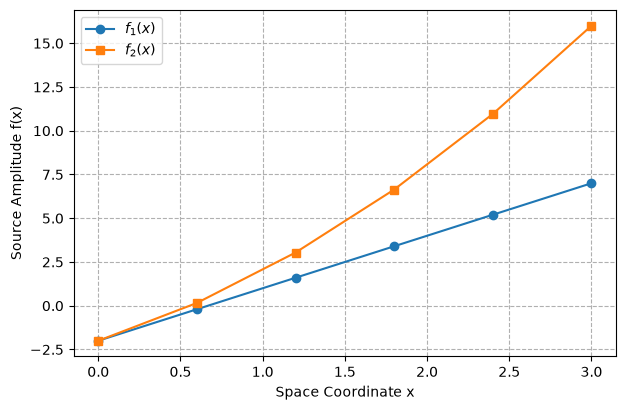

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# TODO: Step 1. Define the analytical source functions as python Callables
def f1(x):
    return 3 * x - 2

def f2(x):
    return x**2 + 3*x - 2
# -------------------------------------------------------------------------

# Step 2. Construct the grid mesh array
n = 5
L = 3.0
x_mesh = np.linspace(0, L, n + 1) 

# Step 3. Generate your evaluation plot using your functions
plt.figure(figsize=(7, 4.5))
plt.plot(x_mesh, f1(x_mesh), '-o', label=r'$f_1(x)$')
plt.plot(x_mesh, f2(x_mesh), '-s', label=r'$f_2(x)$')
plt.xlabel('Space Coordinate x')
plt.ylabel('Source Amplitude f(x)')
plt.legend()
plt.grid(True, ls='--')
plt.show()

### **Question 2: Finite-Difference Approximation Theory (1 p)**
Write down the $\mathcal{O}(h^2)$ central finite-difference (FD) approximation formula for the negative second derivative operator ($-u''$), including the explicit Lagrangian remainder (truncation error) term. 

Define what domain range the arbitrary coordinate value $\xi$ belongs to.

---
For a uniform grid with spacing $h$, the $\mathcal{O}(h^2)$ central finite-difference approximation of the negative second derivative is

$$ \frac{-u(x_i-h)+2u(x_i)-u(x_i+h)}{h^2} + \frac{h^2}{12}u^{(4)}(\xi), $$

or,

$$ \frac{-u_{i-1}+2u_i-u_{i+1}}{h^2} + \frac{h^2}{12}u^{(4)}(\xi). $$

The point $\xi$ appearing in the Lagrangian remainder lies somewhere between the two neighbouring grid points, $ (x_{i-1},x_{i+1}). $ Hence,

$$ \frac{-u_{i-1}+2u_i-u_{i+1}}{h^2} + \mathcal{O}(h^2), $$

showing that the central finite-difference approximation is second order accurate


### **Question 3: Full System of Finite-Difference Equations (1 p)**
Assuming $n=5$, write down the complete system of $n+1 = 6$ finite-difference equations for the entire grid layout, explicitly including the boundary nodes $x_0$ and $x_5$. 

Provide the explicit equations for the source function $f_1(x)$ only.

---
For $n=5$, the grid spacing is $ h=\frac{3}{5}=0.6, $ and the grid points are $ x_0=0, x_1=0.6, x_2=1.2, x_3=1.8, x_4=2.4, x_5=3. $ The boundary conditions give $ u_0=1, $ amd $u_5=2.$

At the four interior grid points, the central finite-difference approximation is

$$ \frac{-u_{i-1}+2u_i-u_{i+1}}{h^2}=f_1(x_i)=3x_i-2, $$

and $h^2=0.36$. Therefore, the complete system of six equations is

$$ u_0=1, $$

$$ \frac{-u_0+2u_1-u_2}{0.36}=-0.2, $$

$$ \frac{-u_1+2u_2-u_3}{0.36}=1.6, $$

$$ \frac{-u_2+2u_3-u_4}{0.36}=3.4, $$

$$ \frac{-u_3+2u_4-u_5}{0.36}=5.2, $$

$$ u_5=2. $$

You could multiply both sides by 0.36. You could also move the boundary values in the interior node equations to the RHS such that all unkowns remain on the LHS.

### **Question 4: Linear Algebraic System Derivation (1 p)**
Using the full system of equations from Question 3, mathematically eliminate the known Dirichlet values $u_0 = 1$ and $u_5 = 2$. 

Show how this elimination reduces the system to a compact linear algebraic problem $A\mathbf{u} = \mathbf{f}$, where $A \in \mathbb{R}^{4 \times 4}$.

---
After eliminating the known boundary values $u_0=1$ and $u_5=2$, the unknown vector contains only the four interior values,

$$
u
=
\begin{bmatrix}
u_1\\
u_2\\
u_3\\
u_4
\end{bmatrix}
$$

The reduced finite-difference system can be written as $ Au=f, $ where

$$ A = \frac{1}{h^2} \begin{bmatrix}
2 & -1 & 0 & 0\\
-1 & 2 & -1 & 0\\
0 & -1 & 2 & -1\\
0 & 0 & -1 & 2
\end{bmatrix} =
\frac{1}{0.36}
\begin{bmatrix}
2 & -1 & 0 & 0\\
-1 & 2 & -1 & 0\\
0 & -1 & 2 & -1\\
0 & 0 & -1 & 2
\end{bmatrix}.
$$

The Dirichlet boundary values modify only the first and last entries of RHS vector:

$$
f =
\begin{bmatrix}
f(x_1)+\dfrac{u_0}{h^2}\\
f(x_2)\\
f(x_3)\\
f(x_4)+\dfrac{u_5}{h^2}
\end{bmatrix} $$

For $f_1(x)=3x-2$,
$$ f_1 =
\begin{bmatrix}
-0.2+\dfrac{1}{0.36}\\
1.6\\
3.4\\
5.2+\dfrac{2}{0.36}
\end{bmatrix} =
\begin{bmatrix}
2.57778\\
1.6\\
3.4\\
10.75556
\end{bmatrix} $$

For $f_2(x)=x^2+3x-2$,
$$ \mathbf{f}_2 = \begin{bmatrix}
0.16+\dfrac{1}{0.36}\\
3.04\\
6.64\\
10.96+\dfrac{2}{0.36}
\end{bmatrix} =
\begin{bmatrix}
2.93778\\
3.04\\
6.64\\
16.51556
\end{bmatrix} $$


### **Question 5(a): Mathematical Structure of the System Matrix (1 p)**
Before implementing the code, state the exact dimension of your internal system matrix $A$ as a function of the number of sub-intervals $n$. 

Write out the algebraic definitions for the entries of the main diagonal ($A_{i,i}$) and the sub/super-diagonals ($A_{i,i-1}$, $A_{i,i+1}$).

---
For $n$ sub-intervals, there are $n+1$ grid points, $ x_0,x_1,...,x_n. $ Since the two Dirichlet boundary values $u_0$ and $u_n$ are known, the unknown vector u contains only the $n-1$ interior values. Hence, the internal finite-difference system matrix has dimension $ A\in\mathbb{R}^{(n-1)\times(n-1)}. $

For the central finite-difference discretization of $-u''$, the matrix is tridiagonal. Its diagonal entries are

$$ A_{i,i}=\frac{2}{h^2}, i=1,...,n-1 $$

while,

$$ A_{i,i-1}=-\frac{1}{h^2}, i=2,...,n-1, $$

and,

$$ A_{i,i+1}=-\frac{1}{h^2}, i=1,...,n-2. $$

All remaining entries are zero. Therefore,

$$ A
=
\frac{1}{h^2}
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0\\
-1 & 2 & -1 & \ddots & \vdots\\
0 & -1 & 2 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & -1\\
0 & \cdots & 0 & -1 & 2
\end{bmatrix}
\in\mathbb{R}^{(n-1)\times(n-1)} $$

### **Question 5(b): Dense Matrix Assembly Function (2 p)**

*Complete the function below to assemble a dense system matrix representing the negative second derivative operator under Dirichlet conditions.*


In [16]:
def assemble_system_matrix(n, L=3.0):
    """
    Constructs the dense tridiagonal FDM matrix A.
    Inputs:
        n : Number of sub-intervals
        L : Physical domain length
    Outputs:
        A : Dense 2D numpy array of size (n-1) x (n-1)
    """
    h = L / n
    
    main_diag = (2 / h**2) * np.ones(n - 1)

    off_diag = (-1 / h**2) * np.ones(n - 2)

    A = (
        np.diag(main_diag)
        + np.diag(off_diag, 1)
        + np.diag(off_diag, -1)
    )
    return A

# Quick local test to verify structure for n=5
A_test = assemble_system_matrix(n=5)
print("Assembled Matrix A (n=5):\n", A_test)


Assembled Matrix A (n=5):
 [[ 5.55555556 -2.77777778  0.          0.        ]
 [-2.77777778  5.55555556 -2.77777778  0.        ]
 [ 0.         -2.77777778  5.55555556 -2.77777778]
 [ 0.          0.         -2.77777778  5.55555556]]


### **Question 6(a): Sizing of the Reduced Right-Hand-Side Vectors (1 p)**
For an arbitrary number of sub-intervals $n$ and an overall grid size of $n+1$ nodes, what is the exact vector size of your interior right-hand-side arrays $\mathbf{f}_1$ and $\mathbf{f}_2$ after boundary elimination? 

State explicitly which nodes (from $x_0$ to $x_n$) are used to evaluate the source function terms inside this reduced system and how the right-hand side vectors are modified after boundary-value elimination.

---
For $n$ sub-intervals, the full grid consists of $n+1$ nodes. Since the Dirichlet values at $x_0$ and $x_n$ are known and eliminated from the system, only the $n-1$ interior nodes remain. Therefore, both reduced right-hand-side vectors have size $f_1,f_2\in\mathbb{R}^{n-1}.$

The source functions are evaluated only at the interior coordinates $x_1,x_2,\ldots,x_{n-1}.$ Thus, after eliminating the known Dirichlet values $u_0$ and $u_n$, their contributions are transferred to the right-hand side. Since the system matrix contains the factor $1/h^2$, the modified RHS becomes

$$ f_j=
\begin{bmatrix}
f_j(x_1)+\dfrac{u_0}{h^2}\\
f_j(x_2)\\
\vdots\\
f_j(x_{n-2})\\
f_j(x_{n-1})+\dfrac{u_n}{h^2}
\end{bmatrix}, j=1,2. $$

For this problem, $ u_0=1, u_n=2, h=\frac{3}{n}, $ so explicitly,

$$ f_j=
\begin{bmatrix}
f_j(x_1)+\dfrac{1}{h^2}\\
f_j(x_2)\\
\vdots\\
f_j(x_{n-2})\\
f_j(x_{n-1})+\dfrac{2}{h^2}
\end{bmatrix}. $$

Hence, the boundary nodes $x_0$ and $x_n$ are not used to evaluate source-function entries in the reduced system; they contribute only through the boundary corrections to the first and last entries of the RHS vector.



### **Question 6(b): Right-Hand-Side Assembly Function (2 p)**

**Your task:** complete the function below to dynamically construct the modified RHS vectors for both $f_1(x)$ and $f_2(x)$ using the eliminated Dirichlet boundary values.

----

*Complete the function below to construct a single, modified RHS vector by passing your spatial grid array and your target function handle.*

In [17]:
def assemble_rhs_vector(x_mesh, f_func, u_left=1.0, u_right=2.0):
    """=
    Constructs a generic, reduced right-hand side vector.
    Inputs:
        x_mesh   : The FULL 1D grid coordinate array (including boundaries)
        f_func  : A python function handle/callable evaluating f(x)
        u_left : Value for Dirichlet boundary conditions u(0)
        u_right : Value for Dirichlet boundary conditions u(L)
    Outputs:
        f_rhs   : Modified RHS vector applied with BC adjustments, length (len(xgrid) - 2)
    """
    n = len(x_mesh) - 1
    L = x_mesh[-1] - x_mesh[0]
    h = L / n
    
    x_interior = x_mesh[1:-1]
    
    # Evaluate the source function dynamically via its functional handle
    f_base = f_func(x_interior)
    
    f_rhs = f_base.copy()

    f_rhs[0] += u_left / h**2
    f_rhs[-1] += u_right / h**2

    # YOUR BOUNDARY SHIFTING CODE HERE (Modify the first and last entries)
    
    # -------------------------------------------------------------------------
    return f_rhs

# Quick local test for sample grid [0,1,2,3,4] 
rhs1 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f1, u_left=1.0, u_right=2.0)
rhs2 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f2, u_left=1.0, u_right=2.0)
print('Assembled rhs vector for f1 source:\n',rhs1)
print('Assembled rhs vector for f2 source:\n',rhs2)


Assembled rhs vector for f1 source:
 [2 4 9]
Assembled rhs vector for f2 source:
 [ 3  8 18]


### **Question 7: Numerical Solver Loop (2 p)**
Now that you have built modules for constructing your system matrix and RHS vetors, write a script execution block to solve the system.

**Your Task:** Complete the code cell below to generate a uniform grid over $x \in [0,3]$ for $n=5$. Call your `assemble_system_matrix` and `assemble_rhs_vector` functions to construct the linear algebra structures, apply `scipy.linalg.solve()`, and pad the boundary conditions ($u(0)=1, u(3)=2$) onto your final internal solution vectors.

In [18]:
import scipy.linalg as la

def solve_poisson_problem(n, L=3.0, u_left=1.0, u_right=2.0):
    # -------------------------------------------------------------------------
     x_full = np.linspace(0.0, L, n + 1)

     A_matrix = assemble_system_matrix(n, L)
     rhs_f1 = assemble_rhs_vector(
        x_mesh=x_full,
        f_func=f1,
        u_left=u_left,
        u_right=u_right )

     rhs_f2 = assemble_rhs_vector(
        x_mesh=x_full,
        f_func=f2,
        u_left=u_left,
        u_right=u_right )

     u1_int = la.solve(A_matrix, rhs_f1)
     u2_int = la.solve(A_matrix, rhs_f2)   

     u1_solution = np.concatenate(([u_left], u1_int, [u_right]))

     u2_solution = np.concatenate(([u_left], u2_int, [u_right]))

     return x_full, u1_solution, u2_solution

# Run solution check for baseline parameter n=5
x_mesh, u1_num, u2_num = solve_poisson_problem(n=5)
print("Numerical solver execution completed.")

Numerical solver execution completed.


### **Question 8: Analytical Comparison and Solution Visualization (1 p)**
Verify your numerical finite difference configurations by overlaying them visually with the true exact solutions.

**Your Task:** Calculate the anlytical solutions $u_1^{ex}$ and $u_2^{ex}$ of the boundary value problem for both source functions. Complete the plotting configuration below using the numerical vectors you computed in Question 7 for $n=5$ and the analytical exact values on your mesh nodes and generate a formatted comparison figure.

--- 
**Plot Guidelines:** Use solid lines for your exact solutions ($u_1^{ex}, u_2^{ex}$), and dashed lines with distinctive circular/square point markers for your discrete approximations ($u_1, u_2$). Include full grid markers, axis labels, and LaTeX legends.

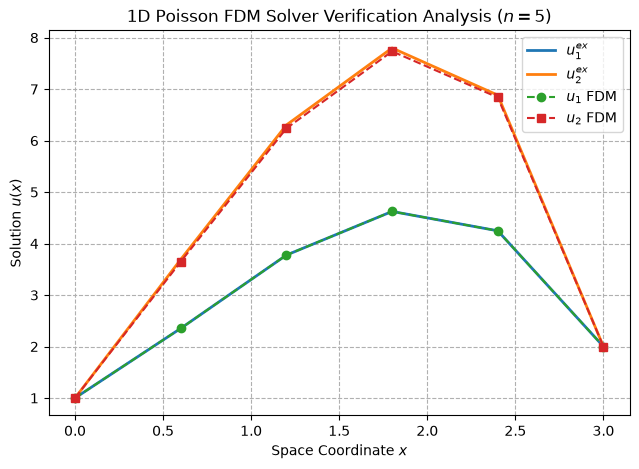

In [19]:
# Step 1: Exact analytical solutions evaluated at the mesh nodes
u1_exact = (-0.5 * x_mesh**3+ x_mesh**2+ (11/6) * x_mesh+ 1 )

u2_exact = ( -(1/12) * x_mesh**4 - 0.5 * x_mesh**3 + x_mesh**2+ (49/12) * x_mesh+ 1)

# Step 2: Construct overlay plot
plt.figure(figsize=(7.5, 5))

plt.plot(x_mesh,u1_exact,'-',linewidth=2,label=r'$u_1^{ex}$')
plt.plot(x_mesh,u2_exact,'-',linewidth=2,label=r'$u_2^{ex}$')

plt.plot(x_mesh,u1_num,'--o',markersize=6,label=r'$u_1$ FDM')
plt.plot(x_mesh,u2_num,'--s',markersize=6,label=r'$u_2$ FDM')

plt.xlabel('Space Coordinate $x$')
plt.ylabel('Solution $u(x)$')
plt.title('1D Poisson FDM Solver Verification Analysis ($n=5$)')
plt.grid(True, ls='--')
plt.legend()

plt.show()

### **Question 9: Continuous vs. Discrete Eigenvalue Analysis (2 p)**
Let the analytical eigenvalues of the continuous negative second-derivative operator $-d^2/dx^2$ be denoted as $\tilde{\lambda}_i$, and the analytical eigenvalues of the corresponding discrete FDM matrix $A$ as $\lambda_i$.

**Your Task:** Using your `assemble_system_matrix` function for $n=5$, numerically calculate the matrix eigenvalues using `np.linalg.eig()`. Sort them from smallest to largest and present them side-by-side with the analytical formulas inside the LaTeX table cell below.

--- 
*Double-click this cell to modify and fill out the values in this $\LaTeX$ Table:* 

| $i$ | Continuous Operator $\tilde{\lambda}_i$ | Discrete Analytical $\lambda_i$ | Numerical Array `np.linalg.eig()` |
|---|---|---|---|
| 1 | 1.096623 | 1.061017 | 1.061017 |
| 2 | 4.386491 | 3.838794 | 3.838794 |
| 3 | 9.869604 | 7.272317 | 7.272317 |
| 4 | 17.545963 | 10.050094 | 10.050094 |

In [20]:
# Step 1: Assemble the test matrix A for n=5
A_eigen = assemble_system_matrix(n=5)

# Step 2: Compute the numerical eigenvalues
raw_evals, _ = np.linalg.eig(A_eigen)

sorted_evals = np.sort(raw_evals)

print("Your computed and sorted numerical eigenvalues:\n", sorted_evals)

Your computed and sorted numerical eigenvalues:
 [ 1.0610167   3.83879448  7.27231664 10.05009441]


### **Question 10(a): Global Error Log-Log Convergence Plot (1 p)**
We want to observe how the overall solution error behaves asymptotically as our discrete uniform mesh grid gets progressively finer.

**Your Task:** Run the convergence nested loop cell below. It will execute your solver dynamically across an array of increasing intervals ($n = [5, 10, 20, 40, 80, 160, 320, 640]$) and plot the Root-Mean-Squared-Errors (RMSE) using a log-log scaling perspective.


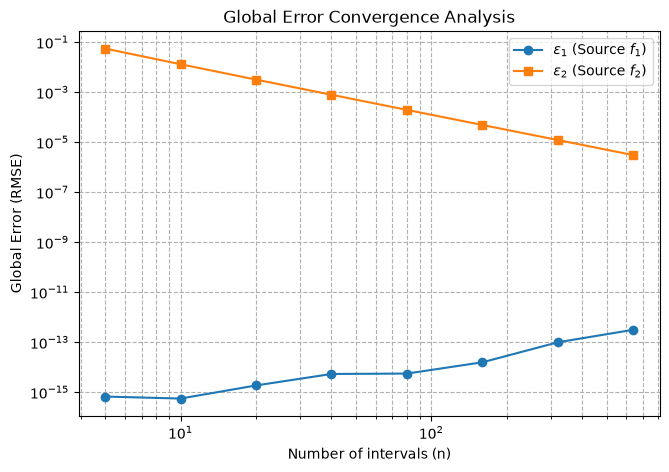

Global RMSE convergence results
--------------------------------------------------------------
     n          h          epsilon_1          epsilon_2
--------------------------------------------------------------
     5   0.600000       6.661338e-16       5.506941e-02
    10   0.300000       5.538766e-16       1.298973e-02
    20   0.150000       1.849359e-15       3.160967e-03
    40   0.075000       5.321236e-15       7.800470e-04
    80   0.037500       5.529035e-15       1.937736e-04
   160   0.018750       1.564049e-14       4.829082e-05
   320   0.009375       9.875439e-14       1.205377e-05
   640   0.004687       3.123847e-13       3.011083e-06

Convergence analysis for epsilon_2
-----------------------------------------------------------------
        n -> 2n        error ratio         order p
-----------------------------------------------------------------
   5 -> 10             4.239457        2.083880
  10 -> 20             4.109417        2.038934
  20 -> 40             

In [24]:
intervals = [5, 10, 20, 40, 80, 160, 320, 640]
errors_f1 = []
errors_f2 = []

for n in intervals:
    # Run your executive modular solver function
    x_mesh, u1_n, u2_n = solve_poisson_problem(n)
    
    # Analytical true benchmarks mapping non-homogeneous boundaries
    u1_exact = (-0.5 * x_mesh**3 + x_mesh**2 + (11/6) * x_mesh + 1)

    u2_exact = ( -(1/12) * x_mesh**4 - 0.5 * x_mesh**3 + x_mesh**2 + (49/12) * x_mesh + 1)
    
    # Calculate Root Mean Squared Errors on interior nodes
    rmse_1 = np.sqrt(np.mean((u1_n[1:-1] - u1_exact[1:-1])**2))
    rmse_2 = np.sqrt(np.mean((u2_n[1:-1] - u2_exact[1:-1])**2))
    
    errors_f1.append(rmse_1)
    errors_f2.append(rmse_2)

# Generate the dynamic log-log error tracking plot
plt.figure(figsize=(7.5, 5))
plt.loglog(intervals, errors_f1, '-o', label=r'$\epsilon_1$ (Source $f_1$)')
plt.loglog(intervals, errors_f2, '-s', label=r'$\epsilon_2$ (Source $f_2$)')
plt.xlabel('Number of intervals (n)')
plt.ylabel('Global Error (RMSE)')
plt.title('Global Error Convergence Analysis')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# Print numerical error values used in the analysis
print("Global RMSE convergence results")
print("-" * 62)
print(f"{'n':>6} {'h':>10} {'epsilon_1':>18} {'epsilon_2':>18}")
print("-" * 62)

for i, n in enumerate(intervals):
    h = 3.0 / n
    print(
        f"{n:6d} "
        f"{h:10.6f} "
        f"{errors_f1[i]:18.6e} "
        f"{errors_f2[i]:18.6e}"
    )

# Compute and print experimental convergence order for f2
print("\nConvergence analysis for epsilon_2")
print("-" * 65)
print(
    f"{'n -> 2n':>15} "
    f"{'error ratio':>18} "
    f"{'order p':>15}"
)
print("-" * 65)

orders_f2 = []

for i in range(len(intervals) - 1):
    # Error reduction when the mesh is refined
    error_ratio = errors_f2[i] / errors_f2[i + 1]
    # Experimental convergence order
    p = np.log(error_ratio) / np.log(2)
    orders_f2.append(p)
    print(
        f"{intervals[i]:4d} -> {intervals[i+1]:<4d} "
        f"{error_ratio:18.6f} "
        f"{p:15.6f}"
    )


### **Question 10(b): Analysis of Convergence Bahavior (2 p)**

Once the graph renders, write a comprehensive analytical report explaining:

1. Why the global error $\epsilon_{1}$ (source $f_{1}$) and the global error $\epsilon_{2}$ (source $f_{2}$) behave differently.
2. Use the global error $\epsilon_{2}$ (source $f_{2}$) to prove that your scheme operates at a true quadratic rate of convergence.

---
The two error curves behave differently because the truncation error of the central finite-difference approximation depends on the fourth derivative of the exact solution. For the second-order approximation,

$$\frac{-u_{i-1}+2u_i-u_{i+1}}{h^2} + \frac{h^2}{12}u^{(4)}(\xi), $$

so the leading discretization error is proportional to $h^2u^{(4)}$. For the first source function $f_1(x)$ the exact solution is $-\frac{1}{2}x^3+x^2+\frac{11}{6}x+1.$ This is a cubic polynomial, so $ u_1^{(4)}(x)=0. $ Hence, the truncation-error term vanishes exactly. The central second-difference formula reproduces the second derivative of a cubic polynomial exactly, so the numerical solution for $f_1$ agrees with the exact solution at the grid nodes up to floating-point round-off. This explains why $\epsilon_1$ is already of order $10^{-15}$ on the coarsest meshes.

For very fine grids, $\epsilon_1$ increases slightly from approximately $10^{-15}$ to $10^{-13}$. This is not caused by discretization error. Instead, it results from finite-precision arithmetic and the increasing condition number of the finite-difference matrix as the grid is refined. Since the actual truncation error for this particular solution is zero, round-off error becomes the dominant contribution.

For the second source function, $f_2$ the exact solution is $ -\frac{1}{12}x^4 -\frac{1}{2}x^3 +x^2 +\frac{49}{12}x +1. $ This solution is quartic and therefore $ u_2^{(4)}(x)=-2\neq0. $ The truncation error does not vanish, and its leading term is proportional to $ h^2.$ Consequently, the global error satisfies $ \epsilon_2 \approx C h^2, $ where $C$ is independent of the grid spacing. Because $h=\frac{3}{n},$ we obtain  $\epsilon_2 \propto n^{-2}$. The numerical errors obtained from the convergence study are approximately

$$
\begin{array}{c|c}
n & \epsilon_2 \\
\hline
5 & 5.507\times10^{-2} \\
10 & 1.299\times10^{-2} \\
20 & 3.161\times10^{-3} \\
40 & 7.800\times10^{-4} \\
80 & 1.938\times10^{-4} \\
160 & 4.829\times10^{-5} \\
320 & 1.205\times10^{-5} \\
640 & 3.011\times10^{-6}
\end{array}
$$

The experimental convergence order between two successive grids is $ \frac{\log(\epsilon_n/\epsilon_{2n})}{\log 2}. $

Using the computed errors gives approximately $ p= 2.084; 2.039; 2.019; 2.009; 2.005; 2.002; 2.001. $

As the mesh is refined, $p\rightarrow2.$ Equivalently, doubling the number of intervals halves the grid spacing, and a second-order method should satisfy

$$ \frac{\epsilon(h)}{\epsilon(h/2)} \approx \frac{Ch^2}{C(h/2)^2} =4. $$

Thus, the error decreases by approximately a factor of four whenever $n$ is doubled. The nearly straight descending $\epsilon_2$ curve on the log-log plot, together with the observed convergence orders approaching $2$, confirms that the finite-difference method exhibits true quadratic convergence.
